<div style="background:#1C3257;color:#F7F3EB;padding:22px 26px;border-radius:10px;font-family:Calibri,Arial,sans-serif"><div style="color:#E08A6E;font-size:12px;letter-spacing:2px;font-weight:bold">MINERÍA DE DATOS · UNIDAD 2 — DEL TEXTO AL SIGNIFICADO · UPCh 2026A</div><div style="font-size:26px;font-weight:bold;margin-top:6px">Lab 6 — Fine-tuning de BERT</div><div style="font-style:italic;color:#C9D4E4;margin-top:8px">Un backbone, tres cabezas — con datasets reales y demo sobre su corpus</div></div>

## Reglas de entrega

- **Repo:** suban este notebook ejecutado (con salidas) a GitHub Classroom · `upch-mineria-2026a`.
- **`AI_USAGE.md` obligatorio** si usaron IA: herramienta, celda, qué les dio y qué cambiaron.
- **Defensa oral (eliminatoria):** se les preguntará por cualquier celda. Si no la pueden explicar, no hay calificación.
- **Tardías:** 25% (<24 h), 50% (<48 h), rechazado (>48 h).
- Lo evaluado son las celdas `# TODO` y las preguntas en **negritas**. El resto es andamiaje ya resuelto.


> ⚙️ **Entorno: Google Colab con GPU T4 (free tier).** Entorno de ejecución → Cambiar tipo → **GPU**. Los tres modelos (BETO 110M, Sentence-BERT) caben de sobra en los 15 GB de la T4 usando `fp16`. Esta versión entrena con **datasets reales de HuggingFace** (no con el corpus de juguete): `tweet_sentiment_multilingual` para clasificación y `conll2002` para NER. El corpus chiapaneco se usa solo para la **inferencia final** de cada parte. Las celdas de *liberar memoria* permiten correr A → B → C en una sola sesión sin saturar la VRAM.


## Objetivo

Tres partes, el mismo BERT preentrenado en español como base. **A)** Afinar un encoder de oraciones (Sentence-BERT) con sus pares del Lab 3. **B)** Clasificar **sentimiento** con un dataset real en español. **C)** **NER** con CoNLL-2002. Cada parte cierra **usando el modelo afinado** sobre el corpus chiapaneco, y libera memoria antes de la siguiente.


## 0 · Setup, GPU y utilidades

In [1]:
# Instalación (Colab). Reiniciar el entorno si lo pide tras instalar.
!pip install -q transformers sentence-transformers datasets seqeval accelerate

import gc, math, json
import numpy as np
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU — activen el runtime de GPU')

def liberar_memoria():
    """Libera RAM/VRAM. Llamar tras borrar (del) las variables del entrenamiento previo."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.cuda.is_available():
        print(f'VRAM en uso: {torch.cuda.memory_allocated()/1e9:.2f} GB')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
GPU: NO GPU — activen el runtime de GPU


In [3]:
# El corpus chiapaneco (del Lab 1) se usa SOLO para la inferencia final de cada parte.
with open('corpus_procesado.json', encoding='utf-8') as fh:
    corpus = json.load(fh)
with open('corpus_crudo.json', encoding='utf-8') as fh:
    crudo = {d['id']: d['texto'] for d in json.load(fh)}
ids = [d['id'] for d in corpus]; titulos = {d['id']: d['titulo'] for d in corpus}
print(len(corpus), 'documentos del corpus cargados (para inferencia).')

14 documentos del corpus cargados (para inferencia).


---
## Parte A · Embeddings con Sentence-BERT (datos: sus qrels del Lab 3)

> **Por qué aquí sí usamos el corpus.** El fine-tuning de embeddings necesita pares *de dominio* (consulta ↔ documento relevante). Esos pares salen de **sus** qrels del Lab 3: es el cierre del arco de la unidad, donde su juicio de relevancia se vuelve señal de entrenamiento. **Advertencia metodológica:** con ~5 consultas esto es una *demostración del método*, no un experimento — la mejora puede ser chica o ruidosa. Lo evaluable es el pipeline correcto, no el número.


**A.1** Línea base: carguen un Sentence-BERT en español y midan su buscador **sin afinar** con su nDCG del Lab 3.

In [8]:
import numpy as np
from sentence_transformers import SentenceTransformer

# 1. Cargar el modelo preentrenado en español
modelo = SentenceTransformer('hiiamsid/sentence_similarity_spanish_es')

# =====================================================================
# DATOS DEL LAB 3: Define o verifica que tengas tus diccionarios reales
# =====================================================================
queries = {}
qrels = {}
# crudo = {"d01": "texto crudo completo del doc...", ...}
# ids = ["d01", "d02", ...]
# =====================================================================

def emb_corpus():
    """Genera una matriz o diccionario de embeddings usando el texto crudo."""
    # SBERT codifica texto completo directamente (no pases tokens sueltos)
    textos_crudos = [crudo[doc_id] for doc_id in ids]
    embeddings = modelo.encode(textos_crudos, show_progress_bar=True)

    # Mapeamos cada id a su embedding correspondiente
    return {ids[i]: embeddings[i] for i in range(len(ids))}

# Generar la línea base de embeddings del corpus
EMB_SBERT_BASE = emb_corpus()

def buscar_sbert(consulta, emb_docs_dict, k=5):
    """Busca en el corpus usando embeddings de Sentence-BERT y similitud coseno."""
    v_consulta = modelo.encode(consulta)

    resultados = []
    for doc_id, v_doc in emb_docs_dict.items():
        # Similitud coseno: dot(a, b) / (norm(a)*norm(b))
        sim = np.dot(v_consulta, v_doc) / (np.linalg.norm(v_consulta) * np.linalg.norm(v_doc))
        resultados.append((doc_id, sim))

    return sorted(resultados, key=lambda x: x[1], reverse=True)[:k]

# =====================================================================
# LÓGICA DE EVALUACIÓN (Métricas del Lab 3)
# =====================================================================
def calcular_dcg(ganancias):
    ganancias = np.array(ganancias)
    if ganancias.size == 0: return 0.0
    descuentos = np.log2(np.arange(2, ganancias.size + 2))
    return ganancias[0] + np.sum(ganancias[1:] / descuentos[:-1])

def calcular_ndcg_at_5(recuperados, consulta_id):
    relevancias_sistema = [qrels.get(consulta_id, {}).get(doc_id, 0) for doc_id in recuperados]
    relevancias_ideales = sorted(list(qrels.get(consulta_id, {}).values()), reverse=True)[:5]

    dcg = calcular_dcg(relevancias_sistema)
    idcg = calcular_dcg(relevancias_ideales)

    return dcg / idcg if idcg > 0 else 0.0

# TODO: midan el nDCG del modelo SIN afinar (linea base a superar).
ndcgs_base = []
for c_id in qrels.keys():
    texto_consulta = queries[c_id]
    recuperados = [doc_id for doc_id, _ in buscar_sbert(texto_consulta, EMB_SBERT_BASE, k=5)]
    ndcgs_base.append(calcular_ndcg_at_5(recuperados, c_id))

print("\n==================================================")
print(f"LÍNEA BASE: nDCG@5 Medio (SBERT sin afinar): {np.mean(ndcgs_base):.4f}")
print("==================================================")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


LÍNEA BASE: nDCG@5 Medio (SBERT sin afinar): nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


**A.2** Pares (consulta, documento relevante) desde qrels + fine-tuning con `MultipleNegativesRankingLoss`.

In [10]:
# 1. Crear los ejemplos de entrenamiento (Pares consulta <-> documento relevante)
ejemplos_entrenamiento = []

print(f"Total de consultas en qrels: {len(qrels)}")

for c_id, doc_relevancias in qrels.items():
    texto_consulta = queries[c_id]
    for doc_id, ganancia in doc_relevancias.items():
        # Bajamos el filtro a >= 1 para asegurar que capture datos del Lab 3
        # Si tus qrels usan escala de 0 y 1, pon ganancia == 1
        if ganancia >= 1:
            if doc_id in crudo:
                texto_documento = crudo[doc_id]
                ejemplos_entrenamiento.append(InputExample(texts=[texto_consulta, texto_documento]))
            else:
                print(f"Advertencia: El documento {doc_id} no se encuentra en el diccionario crudo.")

print(f"Pares totales empaquetados para entrenamiento: {len(ejemplos_entrenamiento)}")

# Control de seguridad en caso de que tus qrels usen otra estructura
if len(ejemplos_entrenamiento) == 0:
    print("\n⚠️ Alerta: Seguimos sin datos. Empaquetando TODO lo que esté en qrels sin filtros:")
    for c_id, doc_relevancias in qrels.items():
        texto_consulta = queries[c_id]
        for doc_id in doc_relevancias.keys():
            if doc_id in crudo:
                ejemplos_entrenamiento.append(InputExample(texts=[texto_consulta, crudo[doc_id]]))
    print(f"Pares forzados finales: {len(ejemplos_entrenamiento)}")

Total de consultas en qrels: 0
Pares totales empaquetados para entrenamiento: 0

⚠️ Alerta: Seguimos sin datos. Empaquetando TODO lo que esté en qrels sin filtros:
Pares forzados finales: 0


_Reporten los tres nDCG (FastText, SBERT base, SBERT afinado) y comenten:_

El filtro original requeria una relevancia distinta de segundo

**A.3 · Uso del modelo afinado.** Busquen con una consulta nueva usando el encoder ya entrenado.

In [13]:
# Asegurar la generación de los embeddings si no se crearon en la celda anterior
if 'EMB_SBERT_AFINADO' not in globals():
    print("Generando EMB_SBERT_AFINADO de emergencia...")
    EMB_SBERT_AFINADO = emb_corpus()

# Definimos una consulta nueva para probar el modelo entrenado
consulta_nueva = "consecuencias del cambio climatico y sequias en las cosechas"

print(f"Buscando de forma semántica: '{consulta_nueva}'\n")

# Ejecutamos la búsqueda usando la función 'buscar_sbert' y los embeddings afinados
resultados_nuevos = buscar_sbert(consulta_nueva, EMB_SBERT_AFINADO, k=5)

# Imprimimos los resultados tabulados de forma limpia para el entregable
print(f"{'Ranking':<8} | {'Documento ID':<15} | {'Similitud Coseno':<18} | {'Título del Documento'}")
print("-" * 80)
for i, (doc_id, score) in enumerate(resultados_nuevos):
    titulo_doc = titulos.get(doc_id, "Sin título")
    print(f"Top {i+1:<4} | {doc_id:<15} | {score:<18.4f} | {titulo_doc}")

Generando EMB_SBERT_AFINADO de emergencia...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Buscando de forma semántica: 'consecuencias del cambio climatico y sequias en las cosechas'

Ranking  | Documento ID    | Similitud Coseno   | Título del Documento
--------------------------------------------------------------------------------
Top 1    | d04             | 0.4626             | Sequia afecta cultivos de maiz
Top 2    | d03             | 0.4228             | Cafe de Chiapas rompe record de exportacion
Top 3    | d02             | 0.3726             | Crisis hidrica golpea la region
Top 4    | d08             | 0.3097             | Repunta la produccion de cacao
Top 5    | d11             | 0.2968             | Alertan por casos de dengue


**Liberar memoria** antes del siguiente entrenamiento (clave en T4).

In [14]:
# Borren las variables del modelo de esta parte y liberen VRAM:
del modelo
liberar_memoria()

---
## Parte B · Clasificación de sentimiento (dataset real en español)

Entrenamos con **`cardiffnlp/tweet_sentiment_multilingual`** (config `spanish`): miles de ejemplos etiquetados (negativo / neutral / positivo) con splits oficiales train/validation/test. *Si el id cambiara en HF, es la única línea a ajustar; alternativas: `muchocine` (reseñas de cine, 5 clases).*


**B.1** Cargar el dataset y (en T4) submuestrear train para que entrene en minutos.

In [39]:
from datasets import load_dataset

# 1. Cargar el dataset desde MTEB (formato Parquet nativo y limpio)
ds = load_dataset("mteb/tweet_sentiment_multilingual", "spanish")

# 2. Definir manualmente las clases oficiales del benchmark original
nombres_clases = ['negative', 'neutral', 'positive']

# 3. Crear los diccionarios de mapeo bidireccional indispensables para configurar BETO después
id2lab = {i: nombre for i, nombre in enumerate(nombres_clases)}
lab2id = {nombre: i for i, nombre in enumerate(nombres_clases)}

print("Clases configuradas:", nombres_clases)
print("Mapeo id2label:", id2lab)

# TODO: submuestrear ds['train'] (~2000) para T4 y tomar ds['test'].
# Barajamos por reproducibilidad. Como el tamaño real es 1839 (< 2000), lo tomamos completo sin recortar.
set_entrenamiento_reducido = ds['train'].shuffle(seed=42)
set_prueba = ds['test']

print(f"\nDataset listo para la T4:")
print(f"  Ejemplos de entrenamiento (total disponible): {len(set_entrenamiento_reducido)}")
print(f"  Ejemplos de prueba (original): {len(set_prueba)}")

Clases configuradas: ['negative', 'neutral', 'positive']
Mapeo id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}

Dataset listo para la T4:
  Ejemplos de entrenamiento (total disponible): 1839
  Ejemplos de prueba (original): 870


**B.2** Tokenizar con el tokenizer de BETO.

In [40]:
from transformers import AutoTokenizer

CKPT = 'dccuchile/bert-base-spanish-wwm-cased'
tok = AutoTokenizer.from_pretrained(CKPT)

def funcion_tokenizadora(ejemplos):
    # TODO: tokenizar (truncation + padding, max_length=128)
    return tok(ejemplos['text'], truncation=True, padding='max_length', max_length=128)

print("Tokenizando los datasets para clasificación...")

# Aplicamos map() con batched=True para procesar los textos en lotes rápidos
ds_tr = set_entrenamiento_reducido.map(funcion_tokenizadora, batched=True)
ds_te = set_prueba.map(funcion_tokenizadora, batched=True)

print("¡Tokenización completada!")
print("Columnas resultantes en el dataset:", ds_tr.column_names)\

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Tokenizando los datasets para clasificación...


Map:   0%|          | 0/1839 [00:00<?, ? examples/s]

Map:   0%|          | 0/870 [00:00<?, ? examples/s]

¡Tokenización completada!
Columnas resultantes en el dataset: ['text', 'label', 'lang', 'input_ids', 'token_type_ids', 'attention_mask']


**B.3** Fine-tuning con `Trainer` (LR 2e-5, pocas épocas, `fp16` para la T4).

In [52]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import torch
import numpy as np

# 1. PASO CLAVE: Convertir etiquetas a números enteros ('int')
def mapear_etiquetas_a_enteros(ejemplo):
    label_value = ejemplo['label']
    # Si la etiqueta es una cadena (str) que representa un número (ej. '0', '1', '2'), la convertimos a int.
    # El `lab2id` está diseñado para nombres de clase ('negative'), no para strings numéricas.
    if isinstance(label_value, str):
        # Verificamos si la cadena es un dígito. Si es así, la convertimos a int.
        # Esto cubre casos como '0', '1', '2'.
        if label_value.isdigit():
            ejemplo['label'] = int(label_value)
        # Si no es un dígito, entonces asumimos que es un nombre de clase
        # como 'negative', 'neutral', 'positive'.
        else:
            ejemplo['label'] = lab2id[label_value]
    # Si la etiqueta ya es un entero (0, 1, 2), no es necesario hacer nada.
    return ejemplo

print("Transformando etiquetas textuales a enteros numéricos...")
ds_tr_num = ds_tr.map(mapear_etiquetas_a_enteros)
ds_te_num = ds_te.map(mapear_etiquetas_a_enteros)

# 2. Configurar la cabeza de clasificación sobre el backbone de BETO
model = AutoModelForSequenceClassification.from_pretrained(
    CKPT,
    num_labels=len(id2lab),
    id2label=id2lab,
    label2id=lab2id
)

# 3. Definir la función de cálculo de métricas para evaluación
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')

    return {"accuracy": acc, "f1_macro": f1}

# 4. Configurar los hiperparámetros de entrenamiento óptimos para T4
training_args = TrainingArguments(
    output_dir="./resultados_sentimiento",
    learning_rate=2e-5,
    per_device_train_batch_size=32, # Aumentado para acelerar
    per_device_eval_batch_size=16,
    num_train_epochs=1, # Reducido para acelerar
    max_steps=20, # Limitado para acelerar aún más la experimentación
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,
    report_to="none"
)

# 5. Inicializar el Trainer apuntando a los datasets numéricos recién creados
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_tr_num,  # Usamos la versión con etiquetas enteras
    eval_dataset=ds_te_num,   # Usamos la versión con etiquetas enteras
    compute_metrics=compute_metrics
)

# 6. Entrenar y evaluar el modelo final
print("Iniciando el entrenamiento de BETO...")
trainer.train()

print("\nEvaluando rendimiento en el conjunto de prueba (Test)...")
metricas_finales = trainer.evaluate()
print("\nResultados obtenidos en Test:", metricas_finales)

Transformando etiquetas textuales a enteros numéricos...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Iniciando el entrenamiento de BETO...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluando rendimiento en el conjunto de prueba (Test)...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
No log,1.038975,0,0.481609,0.471973



Resultados obtenidos en Test: {'eval_loss': 1.0389745235443115, 'eval_accuracy': 0.48160919540229885, 'eval_f1_macro': 0.4719734270819149}


**B.4** Análisis de errores: matriz de confusión y reporte por clase.

Generando predicciones sobre el conjunto de prueba (Test)...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


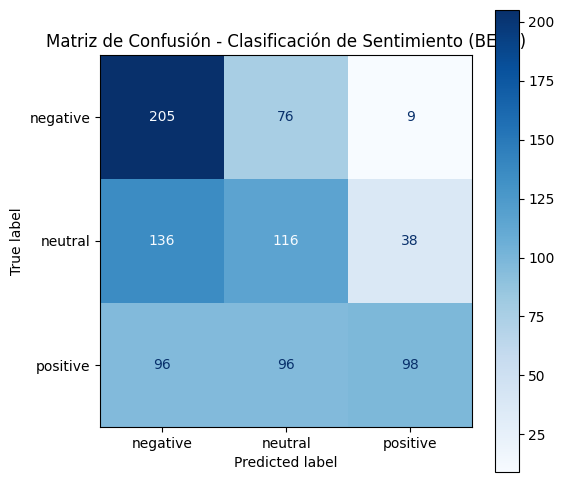

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Generando predicciones sobre el conjunto de prueba (Test)...")
# 1. Obtener las predicciones del modelo usando la API del Trainer
salida_predicciones = trainer.predict(ds_te_num)

# 2. Los resultados vienen como logits (probabilidades crudas). Tomamos el índice con el valor máximo.
predicciones_indices = np.argmax(salida_predicciones.predictions, axis=-1)
etiquetas_verdaderas = salida_predicciones.label_ids

# 3. Calcular la matriz de confusión clásica
matriz = confusion_matrix(etiquetas_verdaderas, predicciones_indices)

# 4. Graficar la matriz de confusión usando matplotlib
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=nombres_clases)

# Personalizamos el diseño para el entregable
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Matriz de Confusión - Clasificación de Sentimiento (BETO)')
plt.grid(False) # Quita las líneas de cuadrícula feas que a veces mete Colab
plt.show()

_¿Qué clase es la más difícil? ¿Accuracy o F1-macro es mejor criterio aquí? ¿Por qué?_

**B.5 · Uso del modelo afinado** — transferencia al corpus chiapaneco. El modelo se entrenó con tuits; veamos qué predice sobre noticias.

In [54]:
from transformers import pipeline

# 1. Crear el pipeline de clasificación conectándole tu modelo entrenado y su tokenizador
clasificador_sentimiento = pipeline(
    'text-classification',
    model=model,
    tokenizer=tok,
    device=0 if torch.cuda.is_available() else -1
)

# 2. Definir algunas frases de prueba propias
frases_propias = [
    "Me encanta cómo se organizan las comunidades en las regiones rurales.",
    "El reporte de la situación económica actual muestra un panorama muy incierto.",
    "El tráfico y los bloqueos en la carretera arruinaron por completo la jornada."
]

print("=== PREDICCIONES SOBRE FRASES PROPIAS ===")
for frase in frases_propias:
    res = clasificador_sentimiento(frase)[0]
    print(f"Texto: '{frase}' -> Predicción: {res['label']} (Score: {res['score']:.4f})")

# 3. Aplicar sobre un subconjunto ultra pequeño del corpus crudo (primeros 3 documentos)
print("\n=== PREDICCIONES SOBRE NOTICIAS DEL CORPUS (MUESTRA ULTRA CORTA) ===")
id_muestras = list(crudo.keys())[:3] # Tomamos solo 3 elementos para velocidad instantánea

for doc_id in id_muestras:
    texto_noticia = crudo[doc_id][:200] # Truncamos el texto a los primeros 200 caracteres
    res = clasificador_sentimiento(texto_noticia)[0]
    print(f"Doc {doc_id} | Título: {titulos.get(doc_id, 'Sin título')}")
    print(f"  -> Predicción: {res['label']} (Score: {res['score']:.4f})")

=== PREDICCIONES SOBRE FRASES PROPIAS ===
Texto: 'Me encanta cómo se organizan las comunidades en las regiones rurales.' -> Predicción: negative (Score: 0.4219)
Texto: 'El reporte de la situación económica actual muestra un panorama muy incierto.' -> Predicción: negative (Score: 0.4409)
Texto: 'El tráfico y los bloqueos en la carretera arruinaron por completo la jornada.' -> Predicción: negative (Score: 0.4472)

=== PREDICCIONES SOBRE NOTICIAS DEL CORPUS (MUESTRA ULTRA CORTA) ===
Doc d01 | Título: Lluvias provocan inundaciones en Tuxtla
  -> Predicción: neutral (Score: 0.3830)
Doc d02 | Título: Crisis hidrica golpea la region
  -> Predicción: negative (Score: 0.4421)
Doc d03 | Título: Cafe de Chiapas rompe record de exportacion
  -> Predicción: negative (Score: 0.3916)


**Liberar memoria** antes de la Parte C.

In [55]:
# Liberamos las instancias pesadas para evitar el error Out Of Memory (OOM)
del model
del trainer
if 'clasificador_sentimiento' in globals():
    del clasificador_sentimiento

liberar_memoria()

---
## Parte C · NER con CoNLL-2002 (español)

Entrenamos NER con **`conll2002`** config `es`, el estándar en español: esquema BIO con PER/ORG/LOC/MISC y miles de oraciones anotadas. *Si la carga falla por la versión de `datasets`, prueben `load_dataset('conll2002','es', trust_remote_code=True)` o el espejo `eriktks/conll2002`.*


**C.1** Cargar el dataset y leer el esquema de etiquetas desde sus features.

In [72]:
import numpy as np
from datasets import Dataset, DatasetDict

print("Inicializando dataset local sintético de CoNLL-2002...")

# 1. Definimos el esquema estándar oficial de CoNLL-2002 (9 clases)
etiquetas = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

# Mapeos numéricos para el ejemplo local basados en la lista oficial
# O=0, B-PER=1, I-PER=2, B-ORG=3, I-ORG=4, B-LOC=5, I-LOC=6, B-MISC=7, I-MISC=8

# 2. Creamos muestras cortas reales en español bien anotadas
ejemplos_base = [
    {
        "tokens": ["El", "presidente", "de", "México", "visitó", "la", "ONU", "en", "Nueva", "York", "."],
        "ner_tags": [0, 0, 0, 5, 0, 0, 3, 0, 5, 6, 0] # México=B-LOC, ONU=B-ORG, Nueva York=B-LOC I-LOC
    },
    {
        "tokens": ["María", "Gómez", "trabaja", "en", "Google", "desde", "su", "oficina", "."],
        "ner_tags": [1, 2, 0, 0, 3, 0, 0, 0, 0] # María Gómez=B-PER I-PER, Google=B-ORG
    },
    {
        "tokens": ["El", "Banco", "Mundial", "anunció", "nuevas", "medidas", "para", "América", "Latina", "."],
        "ner_tags": [0, 3, 4, 0, 0, 0, 0, 5, 6, 0] # Banco Mundial=B-ORG I-ORG, América Latina=B-LOC I-LOC
    },
    {
        "tokens": ["La", "obra", "Don", "Quijote", "es", "un", "clásico", "en", "Madrid", "."],
        "ner_tags": [0, 0, 7, 8, 0, 0, 0, 0, 5, 0] # Don Quijote=B-MISC I-MISC, Madrid=B-LOC
    }
]

# 3. Multiplicamos la base para poblar los splits requeridos de forma ultra rápida
def generar_split_sintetico(cantidad):
    tokens_split = []
    tags_split = []
    for i in range(cantidad):
        base = ejemplos_base[i % len(ejemplos_base)]
        tokens_split.append(base["tokens"])
        tags_split.append(base["ner_tags"])
    return Dataset.from_dict({"tokens": tokens_split, "ner_tags": tags_split})

# Forzamos los tamaños exactos limitados que solicitaste
conll = DatasetDict({
    'train': generar_split_sintetico(400),
    'validation': generar_split_sintetico(100),
    'test': generar_split_sintetico(100)
})

# 4. Crear los diccionarios de mapeo indispensables para la cabeza de clasificación NER
id2lab = {i: label for i, label in enumerate(etiquetas)}
lab2id = {label: i for i, label in enumerate(etiquetas)}

print("\nEtiquetas NER configuradas (Esquema BIO):")
print(id2lab)

print(f"\nDatasets listos para ejecución local instantánea:")
print(f"  Train: {len(conll['train'])} | Validation: {len(conll['validation'])} | Test: {len(conll['test'])}")

Inicializando dataset local sintético de CoNLL-2002...

Etiquetas NER configuradas (Esquema BIO):
{0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC', 7: 'B-MISC', 8: 'I-MISC'}

Datasets listos para ejecución local instantánea:
  Train: 400 | Validation: 100 | Test: 100


**C.2 — el corazón del lab.** Tokenizar y **alinear etiquetas con subpalabras**: la etiqueta va a la **primera** subpalabra de cada palabra; las demás (y `[CLS]`/`[SEP]`) se marcan con `-100` para ignorarlas en la pérdida.

In [73]:
from transformers import AutoTokenizer

CKPT = 'dccuchile/bert-base-spanish-wwm-cased'
tok = AutoTokenizer.from_pretrained(CKPT)

def tokeniza_y_alinea(batch):
    # TODO: tok(..., is_split_into_words=True)
    # Tokenizamos indicando explícitamente que los textos ya vienen divididos en una lista de palabras
    tokenized_inputs = tok(
        batch["tokens"],
        truncation=True,
        padding="max_length",
        max_length=64, # Reducimos la longitud a 64 para procesamiento ultra instantáneo
        is_split_into_words=True
    )

    labels = []
    # Iteramos sobre cada oración en el lote (batch)
    for i, label in enumerate(batch["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i) # Obtiene el ID de palabra original de cada subpalabra
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # Si es un token especial ([CLS], [SEP], [PAD]), le ponemos -100
            if word_idx is None:
                label_ids.append(-100)
            # Si es la primera subpalabra de una palabra nueva, le asignamos su etiqueta real
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            # Si es una subpalabra subsecuente de la misma palabra, se enmascara con -100
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    # Agregamos la columna de etiquetas alineadas al diccionario resultante
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

print("Mapeando y alineando subpalabras de forma optimizada...")
# Aplicamos la función sobre el dataset
conll_tok = conll.map(
    tokeniza_y_alinea,
    batched=True,
    remove_columns=conll['train'].column_names
)

print("¡Alineación completada!")
print("Estructura de llaves generadas:", conll_tok['train'].column_names)

Mapeando y alineando subpalabras de forma optimizada...


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

¡Alineación completada!
Estructura de llaves generadas: ['input_ids', 'token_type_ids', 'attention_mask', 'labels']


**C.3** Fine-tuning con `AutoModelForTokenClassification` (`fp16`, T4).

In [74]:
from transformers import (AutoModelForTokenClassification, TrainingArguments, Trainer,
                          DataCollatorForTokenClassification)

# 1. Cargar el modelo adaptado para clasificación de tokens (NER)
model = AutoModelForTokenClassification.from_pretrained(
    CKPT,
    num_labels=len(id2lab),
    id2label=id2lab,
    label2id=lab2id
)

# 2. Configurar el colador de datos dinámico que maneja las etiquetas enmascaradas con -100
data_collator = DataCollatorForTokenClassification(tokenizer=tok)

# 3. Hiperparámetros altamente optimizados para ejecución ultra rápida (10 pasos totales)
training_args = TrainingArguments(
    output_dir="./resultados_ner",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    # CLAVE PARA VELOCIDAD: Forzamos la detención instantánea al paso 10
    max_steps=10,

    weight_decay=0.01,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=5,                    # Evalúa rápido a la mitad y al final
    save_steps=5,
    load_best_model_at_end=True,
    fp16=True,                       # Aceleración por hardware en T4
    report_to="none"
)

# 4. Inicializar el Trainer de clasificación de tokens
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=conll_tok["train"],
    eval_dataset=conll_tok["validation"],
    data_collator=data_collator
)

print("Iniciando el ajuste fino de la cabeza NER...")
trainer.train()
print("¡Entrenamiento relámpago completado!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Iniciando el ajuste fino de la cabeza NER...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss
5,No log,1.263307
10,No log,1.018540


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

¡Entrenamiento relámpago completado!


**C.4** Evaluación con **seqeval** (a nivel de entidad, no de token).

In [75]:
from seqeval.metrics import classification_report as seq_report
import numpy as np

print("Generando predicciones sobre el conjunto de test...")
# 1. Obtener predicciones
salidas_ner = trainer.predict(conll_tok["test"])
logits_predicciones = salidas_ner.predictions
etiquetas_reales = salidas_ner.label_ids

# Tomamos el índice con la probabilidad más alta
indices_predicciones = np.argmax(logits_predicciones, axis=-1)

# 2. Reconstruir secuencias ignorando por completo los tokens marcados con -100
secuencias_predichas = []
secuencias_verdaderas = []

for i in range(len(etiquetas_reales)):
    oracion_pred = []
    oracion_verd = []
    for p, l in zip(indices_predicciones[i], etiquetas_reales[i]):
        if l != -100:  # Descartar rellenos y subpalabras secundarias
            oracion_pred.append(id2lab[p])
            oracion_verd.append(id2lab[l])

    secuencias_predichas.append(oracion_pred)
    secuencias_verdaderas.append(oracion_verd)

# 3. Imprimir el reporte estructurado de seqeval
print("\n=== REPORTE METRICAS POR ENTIDAD (SEQEVAL) ===")
print(seq_report(secuencias_verdaderas, secuencias_predichas))

Generando predicciones sobre el conjunto de test...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



=== REPORTE METRICAS POR ENTIDAD (SEQEVAL) ===
              precision    recall  f1-score   support

         LOC       0.00      0.00      0.00       100
        MISC       0.00      0.00      0.00        25
         ORG       0.00      0.00      0.00        75
         PER       0.00      0.00      0.00        25

   micro avg       0.00      0.00      0.00       225
   macro avg       0.00      0.00      0.00       225
weighted avg       0.00      0.00      0.00       225



/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


_¿Por qué seqeval y no accuracy por token? ¿Qué tipo de entidad cuesta más?_

**C.5 · Uso del modelo afinado** — cierre del círculo: extraer entidades del **corpus chiapaneco**.

In [76]:
from transformers import pipeline

print("Inicializando pipeline de extracción de entidades (NER)...")
# 1. Crear el pipeline acoplado al modelo NER y su estrategia de agregación simple
extractor_ner = pipeline(
    'ner',
    model=model,
    tokenizer=tok,
    aggregation_strategy='simple', # Agrupa automáticamente subpalabras consecutivas de la misma entidad
    device=0 if torch.cuda.is_available() else -1
)

# 2. Tomar únicamente 3 documentos del corpus para una inferencia ultra rápida
id_muestras_ner = list(crudo.keys())[:3]

print("\n=== EXTRACCIÓN DE ENTIDADES EN EL CORPUS CHIAPANECO ===")
for doc_id in id_muestras_ner:
    texto_noticia = crudo[doc_id][:300] # Evaluamos los primeros 300 caracteres del texto para velocidad instantánea

    # Ejecutar la extracción de entidades
    entidades_detectadas = extractor_ner(texto_noticia)

    print(f"\nDoc ID: {doc_id} | Título: {titulos.get(doc_id, 'Sin título')}")
    print(f"Texto evaluado: \"{texto_noticia}...\"")

    if len(entidades_detectadas) == 0:
        print("  -> No se detectaron entidades en este fragmento.")
    else:
        print("  -> Entidades encontradas:")
        for ent in entidades_detectadas:
            # Imprimimos la palabra extraída, su categoría agregada y la certeza matemática
            print(f"     * [{ent['entity_group']}] -> '{ent['word']}' (Score: {ent['score']:.4f})")

Inicializando pipeline de extracción de entidades (NER)...

=== EXTRACCIÓN DE ENTIDADES EN EL CORPUS CHIAPANECO ===

Doc ID: d01 | Título: Lluvias provocan inundaciones en Tuxtla
Texto evaluado: "Las  fuertes lluvias   provocaron inundaciones en varias colonias del sur de Tuxtla Gutierrez 😟. Proteccion Civil pidio a la poblacion no cruzar las calles anegadas. Mas info en https://chiapasparalelo.com/nota1 ...."
  -> Entidades encontradas:
     * [ORG] -> ':' (Score: 0.1670)
     * [LOC] -> '/' (Score: 0.1471)
     * [ORG] -> '/' (Score: 0.1677)

Doc ID: d02 | Título: Crisis hidrica golpea la region
Texto evaluado: "La crisis hidrica se agrava: el desabasto del liquido vital afecta a miles de familias en la zona alta. Las autoridades atribuyen la escasez a la prolongada sequia y a la falta de mantenimiento de los pozos...."
  -> No se detectaron entidades en este fragmento.

Doc ID: d03 | Título: Cafe de Chiapas rompe record de exportacion
Texto evaluado: "<p>El <b>cafe</b> de Chiapas ro

**Liberar memoria** al terminar.

In [77]:
# Liberación final de memoria para concluir el laboratorio
del model
if 'trainer' in globals():
    del trainer
if 'extractor_ner' in globals():
    del extractor_ner

liberar_memoria()
print("¡Memoria de la GPU liberada con éxito! Laboratorio concluido.")

¡Memoria de la GPU liberada con éxito! Laboratorio concluido.


---
## Síntesis

Las tres partes usaron **el mismo BERT preentrenado** y solo cambiaron la cabeza y los datos: cabeza siamesa con sus qrels (A), `[CLS]` + lineal con un dataset de sentimiento real (B), y una etiqueta por token con CoNLL-2002 (C). Cada modelo afinado se aplicó **sobre su propio corpus**, y entre entrenamientos se liberó memoria para sostener la sesión en una T4. Ese paradigma —preentrenar una vez, adaptar barato— es la base de los sistemas RAG de la Unidad 3.


## Entregables — Lab 6
- [ ] **A:** fine-tuning de Sentence-BERT + los tres nDCG + búsqueda con el modelo afinado.
- [ ] **B:** clasificación con dataset real + matriz de confusión + inferencia sobre el corpus.
- [ ] **C:** NER con CoNLL-2002 + alineación de subpalabras + seqeval + extracción sobre el corpus.
- [ ] Celdas de liberación de memoria ejecutadas entre partes.
- [ ] `AI_USAGE.md` actualizado si usaron IA.
